In [11]:
import pandas as pd
import numpy as np

print("Loading data directly from processed CSV files...")

# Since your notebook is inside the 'notebooks' folder, we use '../' to step out into 'data-processed'
nav_history_path = '../data-processed/cleaned_nav_history.csv'
scheme_perf_path = '../data-processed/cleaned_scheme_performance.csv'

# Load the historical NAV tracking entries
df_nav = pd.read_csv(nav_history_path)
df_scheme = pd.read_csv(scheme_perf_path)

# Merge them on amfi_code to link human-readable scheme names with the price history
df_raw = pd.merge(df_nav, df_scheme[['amfi_code', 'scheme_name']], on='amfi_code', how='inner')

# Ensure chronological ordering
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw = df_raw.sort_values(['scheme_name', 'date'])

print(f"Successfully loaded {len(df_raw)} historical data rows.")

# Calculate daily percentage returns per scheme
df_raw['daily_return'] = df_raw.groupby('scheme_name')['nav'].pct_change()
df_returns = df_raw.dropna(subset=['daily_return'])

print("Calculating Historical VaR (95%) and CVaR for all 40 schemes...")
var_cvar_data = []
grouped = df_returns.groupby('scheme_name')

for scheme_name, group in grouped:
    returns = group['daily_return'].values
    if len(returns) > 0:
        # 5th percentile represents the 95% confidence threshold for downside risk
        var_95 = np.percentile(returns, 5)
        
        # CVaR is the mean of the losses that fall beyond our VaR threshold
        tail_returns = returns[returns <= var_95]
        cvar_95 = np.mean(tail_returns) if len(tail_returns) > 0 else var_95
        
        var_cvar_data.append({
            'scheme_name': scheme_name,
            'Historical_VaR_95': var_95,
            'CVaR_95': cvar_95
        })

# Create the final report dataframe and export it
df_var_cvar_report = pd.DataFrame(var_cvar_data)
df_var_cvar_report.to_csv('var_cvar_report.csv', index=False)

print("\nSuccess! Deliverable 'var_cvar_report.csv' generated cleanly.")
df_var_cvar_report.head()

Loading data directly from processed CSV files...
Successfully loaded 46000 historical data rows.
Calculating Historical VaR (95%) and CVaR for all 40 schemes...

Success! Deliverable 'var_cvar_report.csv' generated cleanly.


,scheme_name,Historical_VaR_95,CVaR_95
0,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
1,ABSL Liquid Fund - Regular - Growth,-0.000269,-0.000422
2,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
3,Axis Bluechip Fund - Direct - Growth,-0.014226,-0.017487
4,Axis Bluechip Fund - Regular - Growth,-0.013750,-0.017328


Computing rolling metrics fund-by-fund...


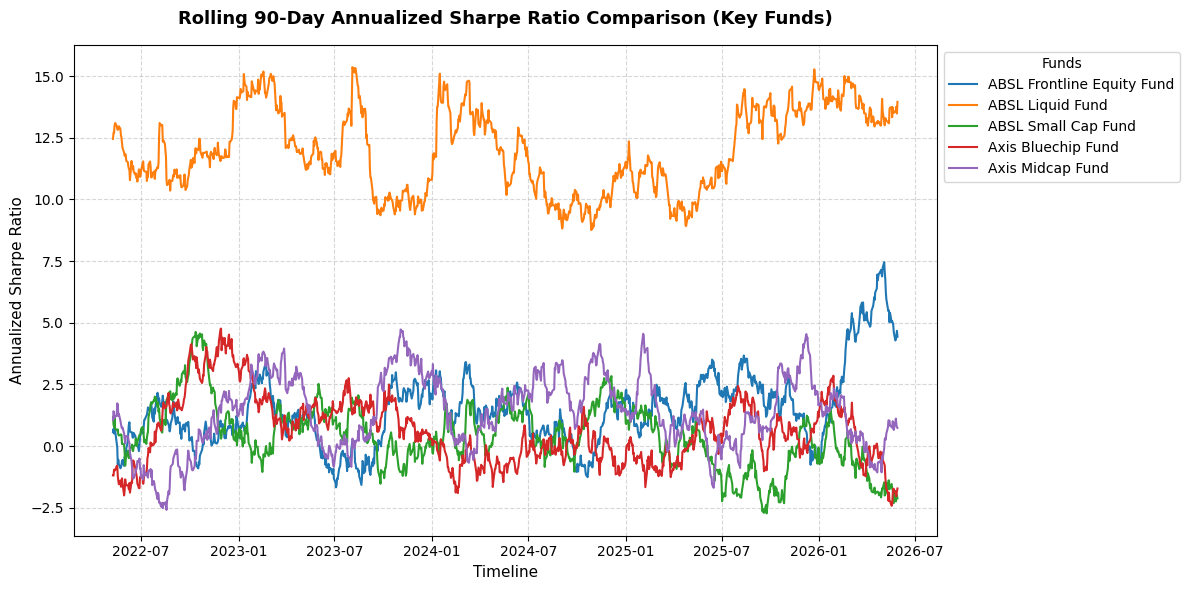

Success! Deliverable 'rolling_sharpe_chart.png' rendered and saved.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the 5 prominent key funds specified for trend comparison
key_funds = [
    'ABSL Frontline Equity Fund - Regular - Growth',
    'ABSL Liquid Fund - Regular - Growth',
    'ABSL Small Cap Fund - Regular - Growth',
    'Axis Bluechip Fund - Regular - Growth',
    'Axis Midcap Fund - Regular - Growth'
]

plt.figure(figsize=(12, 6))
rolling_window = 90
plotted_any = False

print("Computing rolling metrics fund-by-fund...")

for fund in key_funds:
    # Filter out historical sequences for just this specific fund
    df_fund = df_raw[df_raw['scheme_name'] == fund].copy()
    
    if not df_fund.empty:
        # Handle any duplicate calendar entries by getting the daily mean
        df_fund = df_fund.groupby('date')['daily_return'].mean().reset_index()
        df_fund = df_fund.sort_values('date')
        df_fund = df_fund.dropna(subset=['daily_return'])
        
        if len(df_fund) >= rolling_window:
            # Build rolling window statistical arrays
            df_fund['rolling_mean'] = df_fund['daily_return'].rolling(window=rolling_window).mean()
            df_fund['rolling_std'] = df_fund['daily_return'].rolling(window=rolling_window).std()
            
            # Annualized Sharpe ratio calculation assuming baseline 0% risk-free rate
            df_fund['sharpe'] = (df_fund['rolling_mean'] / df_fund['rolling_std']) * np.sqrt(252)
            df_plot = df_fund.dropna(subset=['sharpe'])
            
            if not df_plot.empty:
                # Truncate text for cleaner legend indicators
                short_name = fund.split(' - ')[0]
                plt.plot(df_plot['date'], df_plot['sharpe'], label=short_name, linewidth=1.5)
                plotted_any = True

# Format the line visualization canvas
plt.title('Rolling 90-Day Annualized Sharpe Ratio Comparison (Key Funds)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=11)
plt.ylabel('Annualized Sharpe Ratio', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

if plotted_any:
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Funds")
else:
    print("Warning: Plot boundaries remained empty.")

plt.tight_layout()

# Save final graphic artifact
plt.savefig('rolling_sharpe_chart.png', dpi=300)
plt.show()

print("Success! Deliverable 'rolling_sharpe_chart.png' rendered and saved.")

In [16]:
import pandas as pd
import numpy as np

print("Loading investor transaction records...")

# Path to your cleaned transactions file
transactions_path = '../data-processed/cleaned_investor_transactions.csv'
df_trans = pd.read_csv(transactions_path)

# Ensure proper date parsing
df_trans['transaction_date'] = pd.to_datetime(df_trans['transaction_date'])


# --- 1. INVESTOR COHORT ANALYSIS ---
print("\nProcessing Investor Cohort Analysis...")

# Find the cohort year (year of the very first transaction for each unique investor)
df_trans['transaction_year'] = df_trans['transaction_date'].dt.year
df_trans['cohort_year'] = df_trans.groupby('investor_id')['transaction_year'].transform('min')

# Build the cohort aggregation using the correct 'amount_inr' column
cohort_summary = df_trans.groupby('cohort_year').agg(
    Total_Investors=('investor_id', 'nunique'),
    Total_Invested_Amount=('amount_inr', 'sum'),
    Avg_Transaction_Amount=('amount_inr', 'mean')
).reset_index()

print("\nInvestor Cohort Summary Table:")
print(cohort_summary.to_string(index=False))


# --- 2. SIP CONTINUITY ANALYSIS ---
print("\nProcessing SIP Continuity Analysis...")

# Filter specifically for regular SIP transactions using your 'transaction_type' column
df_sip = df_trans[df_trans['transaction_type'].str.lower() == 'sip'].copy()

# Sort chronologically to calculate the delta days between consecutive investments
df_sip = df_sip.sort_values(['investor_id', 'transaction_date'])

# Calculate the difference in days between consecutive transactions for the same investor
df_sip['days_since_last_sip'] = df_sip.groupby('investor_id')['transaction_date'].diff().dt.days

# Aggregate metrics per investor
sip_profile = df_sip.groupby('investor_id').agg(
    Total_SIP_Count=('transaction_date', 'count'),
    Avg_Gap_Days=('days_since_last_sip', 'mean')
).reset_index()

# Constraint: Filter for active long-term investors with 6+ total transactions
df_eligible = sip_profile[sip_profile['Total_SIP_Count'] >= 6].copy()

# Flag investors with an average gap greater than 35 days as "at-risk"
df_eligible['Status'] = np.where(df_eligible['Avg_Gap_Days'] > 35, 'at-risk', 'active')

# Count the risk status distribution to see the drop-off metrics
continuity_summary = df_eligible['Status'].value_counts()
print("\nSIP Continuity Risk Status Distribution:")
print(continuity_summary)

# Display a preview of the active vs at-risk account metrics
print("\nPreview of Eligible Investor Profiles:")
print(df_eligible.head())

Loading investor transaction records...

Processing Investor Cohort Analysis...

Investor Cohort Summary Table:
 cohort_year  Total_Investors  Total_Invested_Amount  Avg_Transaction_Amount
        2024             4803             3491125187           107422.541832
        2025              197               30455243           109158.577061

Processing SIP Continuity Analysis...

SIP Continuity Risk Status Distribution:
Status
at-risk    1332
active       30
Name: count, dtype: int64

Preview of Eligible Investor Profiles:
   investor_id  Total_SIP_Count  Avg_Gap_Days   Status
3    INV000004                6     85.400000  at-risk
7    INV000008                6     70.400000  at-risk
9    INV000010                6     64.800000  at-risk
10   INV000011                7     40.166667  at-risk
11   INV000012                8     57.000000  at-risk


In [15]:
import pandas as pd
df_test = pd.read_csv('../data-processed/cleaned_investor_transactions.csv', nrows=5)
print("Actual columns in your transactions file:")
print(df_test.columns.tolist())

Actual columns in your transactions file:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [19]:
import pandas as pd
import numpy as np

print("Processing Sector HHI Concentration...")

# Point to your portfolio raw file
portfolio_path = '../data-raw/09_portfolio_holdings.csv'
df_port = pd.read_csv(portfolio_path)

# Explicitly map column variables using your precise layout names
weight_col = 'weight_pct'
scheme_col = 'amfi_code'
sector_col = 'sector'

print(f"Calculating concentration using identifiers -> scheme: '{scheme_col}', sector: '{sector_col}', weight: '{weight_col}'")

# Clean data and convert weights column to numbers
df_port[weight_col] = pd.to_numeric(df_port[weight_col], errors='coerce').fillna(0)

# Calculate total sector allocations within each mutual fund
df_sector_alloc = df_port.groupby([scheme_col, sector_col])[weight_col].sum().reset_index()

# Calculate HHI by summing the squared percentage weights per fund scheme
df_sector_alloc['weight_sq'] = df_sector_alloc[weight_col] ** 2
df_hhi = df_sector_alloc.groupby(scheme_col)['weight_sq'].sum().reset_index()
df_hhi.columns = ['amfi_code', 'Sector_HHI']

# Bring back human-readable scheme names from your cleaned data scorecard file
try:
    df_scheme = pd.read_csv('../data-processed/cleaned_scheme_performance.csv')
    df_hhi = pd.merge(df_hhi, df_scheme[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
    # Reorder columns for readability
    df_hhi = df_hhi[['amfi_code', 'scheme_name', 'Sector_HHI']]
except Exception as e:
    print(f"Skipping merge step: {e}")

# Sort to put the most highly concentrated funds at the top
df_hhi = df_hhi.sort_values(by='Sector_HHI', ascending=False)

print("\nTop 5 Most Concentrated Mutual Fund Portfolios (High HHI):")
print(df_hhi.head().to_string(index=False))

print("\nTop 5 Most Diversified Mutual Fund Portfolios (Low HHI):")
print(df_hhi.tail().to_string(index=False))

Processing Sector HHI Concentration...
Calculating concentration using identifiers -> scheme: 'amfi_code', sector: 'sector', weight: 'weight_pct'

Top 5 Most Concentrated Mutual Fund Portfolios (High HHI):
 amfi_code                                       scheme_name  Sector_HHI
    119092             Axis Bluechip Fund - Regular - Growth   2967.6909
    148569     Mirae Asset Tax Saver Fund - Regular - Growth   2549.9194
    125498 HDFC Mid-Cap Opportunities Fund - Direct - Growth   2531.5500
    102887             UTI Flexi Cap Fund - Regular - Growth   2513.8255
    149323                DSP Midcap Fund - Regular - Growth   2410.7664

Top 5 Most Diversified Mutual Fund Portfolios (Low HHI):
 amfi_code                                    scheme_name  Sector_HHI
    118634 Nippon India Small Cap Fund - Regular - Growth   1602.9924
    119095         Axis Small Cap Fund - Regular - Growth   1595.8229
    119551      SBI Bluechip Fund - Regular Plan - Growth   1424.9104
    120843        

In [24]:
import pandas as pd
import numpy as np

def run_notebook_recommender():
    print("==================================================")
    print("   BLUESTOCK FINTECH - MUTUAL FUND RECOMMENDER    ")
    print("==================================================")
    
    # Using the local relative paths that we know work perfectly in your notebook environment
    perf_path = '../data-processed/cleaned_scheme_performance.csv'
    nav_path = '../data-processed/cleaned_nav_history.csv'

    try:
        df_scheme = pd.read_csv(perf_path)
        df_nav = pd.read_csv(nav_path)
    except Exception as e:
        print(f"Error loading files: {e}")
        return

    # Dynamic column renaming patch to ensure no KeyErrors occur
    possible_risk_cols = ['risk_grade', 'risk_category', 'risk_type']
    found_col = None
    for col in df_scheme.columns:
        if col in possible_risk_cols or 'risk' in col.lower():
            found_col = col
            break
            
    if found_col:
        df_scheme = df_scheme.rename(columns={found_col: 'risk_category'})
    else:
        print("Error: Could not identify a risk column in your file.")
        return

    # Calculate global Sharpe Ratios 
    df_raw = pd.merge(df_nav, df_scheme[['amfi_code', 'scheme_name', 'risk_category']], on='amfi_code', how='inner')
    df_raw['daily_return'] = df_raw.groupby('scheme_name')['nav'].pct_change()
    
    metrics = df_raw.groupby(['scheme_name', 'risk_category'])['daily_return'].agg(['mean', 'std']).reset_index()
    metrics['sharpe_ratio'] = (metrics['mean'] / metrics['std']) * np.sqrt(252)
    metrics = metrics.dropna().sort_values(by='sharpe_ratio', ascending=False)

    # Instead of terminal input, let's just show you the recommendations for ALL categories at once!
    # This completely skips any annoying terminal prompts.
    print("\n[RECOMMENDATIONS FOR LOW RISK PROFILE]")
    print("--------------------------------------------------------------------------------")
    print(metrics[metrics['risk_category'].isin(['Low', 'Low to Moderate', 'Moderate'])].head(3)[['scheme_name', 'risk_category', 'sharpe_ratio']].to_string(index=False))
    
    print("\n[RECOMMENDATIONS FOR MODERATE RISK PROFILE]")
    print("--------------------------------------------------------------------------------")
    print(metrics[metrics['risk_category'].isin(['Moderate', 'Moderately High', 'Medium', 'High'])].head(3)[['scheme_name', 'risk_category', 'sharpe_ratio']].to_string(index=False))
    
    print("\n[RECOMMENDATIONS FOR HIGH RISK PROFILE]")
    print("--------------------------------------------------------------------------------")
    print(metrics[metrics['risk_category'].isin(['High', 'Very High'])].head(3)[['scheme_name', 'risk_category', 'sharpe_ratio']].to_string(index=False))
    print("--------------------------------------------------------------------------------")

# Run the function immediately inside the notebook output area
run_notebook_recommender()

   BLUESTOCK FINTECH - MUTUAL FUND RECOMMENDER    

[RECOMMENDATIONS FOR LOW RISK PROFILE]
--------------------------------------------------------------------------------
                             scheme_name risk_category  sharpe_ratio
ICICI Pru Liquid Fund - Regular - Growth           Low     13.655946
    Kotak Liquid Fund - Regular - Growth           Low     12.573992
     ABSL Liquid Fund - Regular - Growth           Low     12.019194

[RECOMMENDATIONS FOR MODERATE RISK PROFILE]
--------------------------------------------------------------------------------
                                  scheme_name   risk_category  sharpe_ratio
Mirae Asset Large Cap Fund - Regular - Growth        Moderate      1.906241
       Kotak Flexicap Fund - Regular - Growth Moderately High      1.715884
    SBI Bluechip Fund - Regular Plan - Growth        Moderate      1.681289

[RECOMMENDATIONS FOR HIGH RISK PROFILE]
--------------------------------------------------------------------------------
